# Practical Statistics for Data Scientists
## Chapter 2 — Data and Sampling Distributions

**Code Reproduction + Theoretical Deep-Dive**

### Tujuan Pembelajaran
Chapter 2 membahas bagaimana data diperoleh dari populasi, bagaimana proses sampling dapat menghasilkan bias, serta bagaimana distribusi statistik sampel membantu kita melakukan inferensi.

Materi utama chapter ini meliputi **random sampling, sample bias, sampling distribution, Central Limit Theorem (CLT), standard error, bootstrap, confidence interval**, dan beberapa distribusi probabilitas penting: **Normal, Student's t, Binomial, Chi-Square, F, Poisson, Exponential, dan Weibull**.

Notebook ini mempertahankan organisasi konsep Chapter 2, tetapi implementasi kode ditulis ulang dan dilengkapi visualisasi serta interpretasi.

## 1. Import Library dan Konfigurasi

Library yang digunakan mencakup NumPy untuk simulasi numerik, pandas untuk tabulasi, Matplotlib untuk visualisasi, dan SciPy untuk distribusi probabilitas serta statistik.

Simulasi dibuat dengan random seed agar hasil dapat direproduksi ketika notebook dijalankan ulang.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats

np.random.seed(42)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

print("Library berhasil dimuat.")

Library berhasil dimuat.


## 2. Random Sampling and Sample Bias

**Population** adalah keseluruhan unit yang menjadi target analisis, sedangkan **sample** adalah sebagian unit yang dipilih dari population.

Random sampling bertujuan memberi setiap anggota population kesempatan yang sama untuk terpilih. Namun, sampling yang besar belum tentu menghasilkan estimasi yang baik apabila prosedur pemilihannya menghasilkan bias.

Dalam data science, kualitas sampel mencakup representativeness, completeness, consistency, cleanliness, dan accuracy. Karena itu, menambah jumlah data tidak otomatis menghilangkan masalah bias.

In [2]:
# Membuat population sintetis yang memiliki dua kelompok.
rng = np.random.default_rng(42)

population = pd.DataFrame({
    "income": np.concatenate([
        rng.normal(45_000, 7_000, 8000),
        rng.normal(90_000, 12_000, 2000)
    ])
})

population["income"] = population["income"].clip(lower=15_000)

print("Ukuran population:", len(population))
print("Population mean  :", population["income"].mean())
print("Population median:", population["income"].median())

Ukuran population: 10000
Population mean  : 53916.36343854865
Population median: 47164.37874184926


### Simple Random Sample

Contoh berikut mengambil sample secara acak tanpa mengganti observasi. Sample mean dibandingkan dengan population mean untuk menunjukkan bahwa estimasi dari sample dapat berbeda dari nilai population sebenarnya.

In [3]:
sample = population.sample(n=200, random_state=42)

comparison = pd.DataFrame({
    "Statistic": ["Population", "Random Sample"],
    "Mean Income": [
        population["income"].mean(),
        sample["income"].mean()
    ]
})

display(comparison)

,Statistic,Mean Income
0,Population,"53,916.3634"
1,Random Sample,"53,728.0621"


**Interpretasi:** Sample mean tidak harus sama persis dengan population mean. Perbedaan tersebut merupakan sampling variability, yaitu variasi alami yang muncul karena kita hanya mengamati sebagian population.

### Visualisasi 1 — Population vs Random Sample

Visualisasi berikut memperlihatkan distribusi income population dan sample secara berdampingan. Tujuannya bukan sekadar membandingkan ukuran data, tetapi melihat apakah sample mempertahankan bentuk distribusi population.

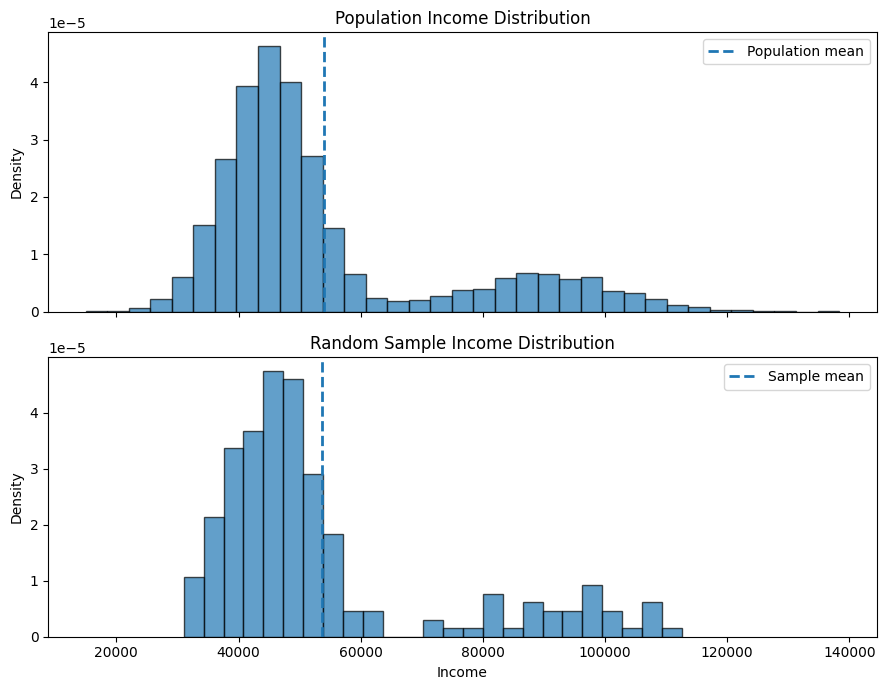

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(9, 7), sharex=True)

axes[0].hist(population["income"], bins=35, density=True, alpha=0.7, edgecolor="black")
axes[0].axvline(population["income"].mean(), linestyle="--", linewidth=2, label="Population mean")
axes[0].set_title("Population Income Distribution")
axes[0].set_ylabel("Density")
axes[0].legend()

axes[1].hist(sample["income"], bins=25, density=True, alpha=0.7, edgecolor="black")
axes[1].axvline(sample["income"].mean(), linestyle="--", linewidth=2, label="Sample mean")
axes[1].set_title("Random Sample Income Distribution")
axes[1].set_xlabel("Income")
axes[1].set_ylabel("Density")
axes[1].legend()

plt.tight_layout()
plt.show()

**Caption / Penjelasan Chart:** Distribusi sample secara umum mengikuti bentuk population, tetapi lebih kasar karena jumlah observasinya jauh lebih sedikit. Perbedaan posisi mean menunjukkan sampling variability dan bukan otomatis kesalahan sampling.

## 3. Bias dan Random Selection

**Bias** terjadi ketika prosedur sampling secara sistematis membuat sample berbeda dari population target. Contohnya adalah mengambil responden hanya dari kelompok yang mudah dijangkau.

Random selection mengurangi risiko systematic selection bias, meskipun tidak menjamin sample tertentu akan selalu identik dengan population.

In [5]:
# Contoh selection bias: mengambil hanya 10% observasi berpenghasilan tertinggi.
biased_sample = population.nlargest(200, "income")

bias_demo = pd.DataFrame({
    "Group": ["Population", "Random sample", "Biased sample"],
    "Mean income": [
        population["income"].mean(),
        sample["income"].mean(),
        biased_sample["income"].mean()
    ]
})

display(bias_demo)

,Group,Mean income
0,Population,"53,916.3634"
1,Random sample,"53,728.0621"
2,Biased sample,"111,292.8079"


**Interpretasi:** Biased sample menghasilkan mean yang jauh lebih tinggi karena mekanisme pemilihannya memang tidak representatif terhadap population. Ini menunjukkan mengapa prosedur sampling lebih penting daripada sekadar jumlah observasi.

### Visualisasi 2 — Dampak Selection Bias

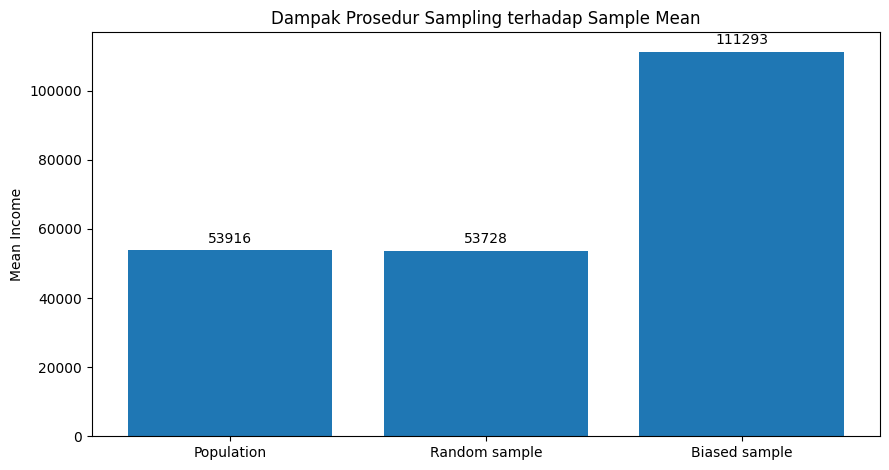

In [6]:
fig, ax = plt.subplots(figsize=(9, 4.8))

labels = bias_demo["Group"]
values = bias_demo["Mean income"]

bars = ax.bar(labels, values)
ax.set_title("Dampak Prosedur Sampling terhadap Sample Mean")
ax.set_ylabel("Mean Income")
ax.bar_label(bars, fmt="%.0f", padding=3)

plt.tight_layout()
plt.show()

**Caption / Penjelasan Chart:** Random sample menghasilkan mean yang relatif dekat dengan population mean, sedangkan biased sample menghasilkan estimasi yang lebih tinggi karena hanya memilih observasi berpenghasilan tinggi.

## 4. Sample Mean versus Population Mean

Population mean biasanya tidak diketahui dalam masalah nyata. Sample mean digunakan sebagai estimator.

Jika kita mengambil banyak sample acak dengan ukuran sama, masing-masing sample akan menghasilkan mean yang sedikit berbeda. Kumpulan sample mean tersebut membentuk **sampling distribution of the mean**.

In [7]:
# Mengambil 1,000 random samples dan menghitung mean masing-masing.
n_samples = 1000
sample_size = 50

sample_means = np.array([
    population["income"].sample(n=sample_size, random_state=i).mean()
    for i in range(n_samples)
])

print("Population mean:", population["income"].mean())
print("Mean of sample means:", sample_means.mean())
print("SD of sample means:", sample_means.std(ddof=1))

Population mean: 53916.36343854865
Mean of sample means: 53731.38303768937
SD of sample means: 2715.5181208937374


## 5. Sampling Distribution of a Statistic

**Sampling distribution** adalah distribusi nilai suatu statistik yang diperoleh dari banyak sample yang diambil menggunakan prosedur sampling yang sama.

Hal pentingnya adalah distribusi data individual dan distribusi sample statistic tidak selalu memiliki bentuk yang sama. Sample mean biasanya lebih stabil dan, seiring bertambahnya ukuran sample, distribusinya cenderung mendekati bentuk normal.

### Visualisasi 3 — Sampling Distribution of the Mean

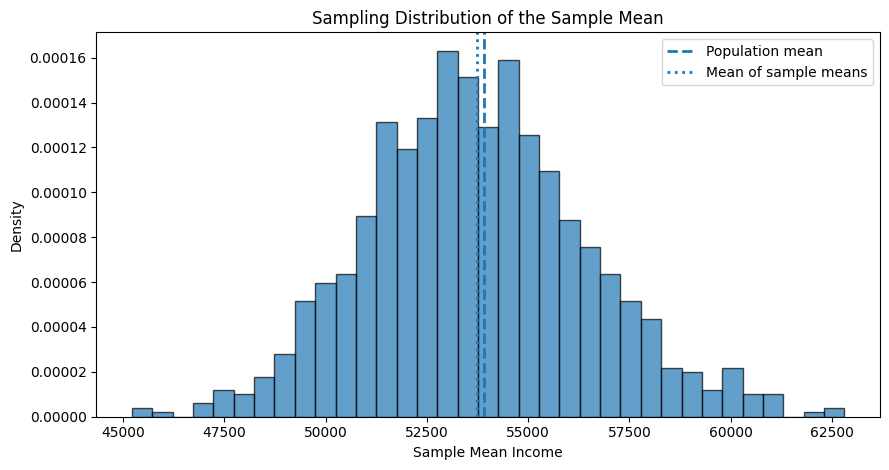

In [8]:
fig, ax = plt.subplots(figsize=(9, 4.8))

ax.hist(sample_means, bins=35, density=True, alpha=0.7, edgecolor="black")
ax.axvline(population["income"].mean(), linestyle="--", linewidth=2, label="Population mean")
ax.axvline(sample_means.mean(), linestyle=":", linewidth=2, label="Mean of sample means")

ax.set_title("Sampling Distribution of the Sample Mean")
ax.set_xlabel("Sample Mean Income")
ax.set_ylabel("Density")
ax.legend()

plt.tight_layout()
plt.show()

**Caption / Penjelasan Chart:** Distribusi sample mean lebih sempit daripada distribusi income individual. Pusatnya berada dekat population mean. Ini menunjukkan bahwa aggregating observations into a statistic dapat menghasilkan estimasi yang lebih stabil.

## 6. Central Limit Theorem (CLT)

**Central Limit Theorem** menyatakan bahwa, dalam kondisi umum, distribusi sample mean akan semakin mendekati distribusi normal ketika ukuran sample bertambah, dengan asumsi observasi independen dan kondisi varians yang sesuai.

CLT sangat penting karena memungkinkan penggunaan pendekatan normal untuk inferensi terhadap mean meskipun distribusi population awal tidak normal.

Secara konseptual:

**SE(mean) ≈ σ / √n**

Semakin besar `n`, semakin kecil standard error.

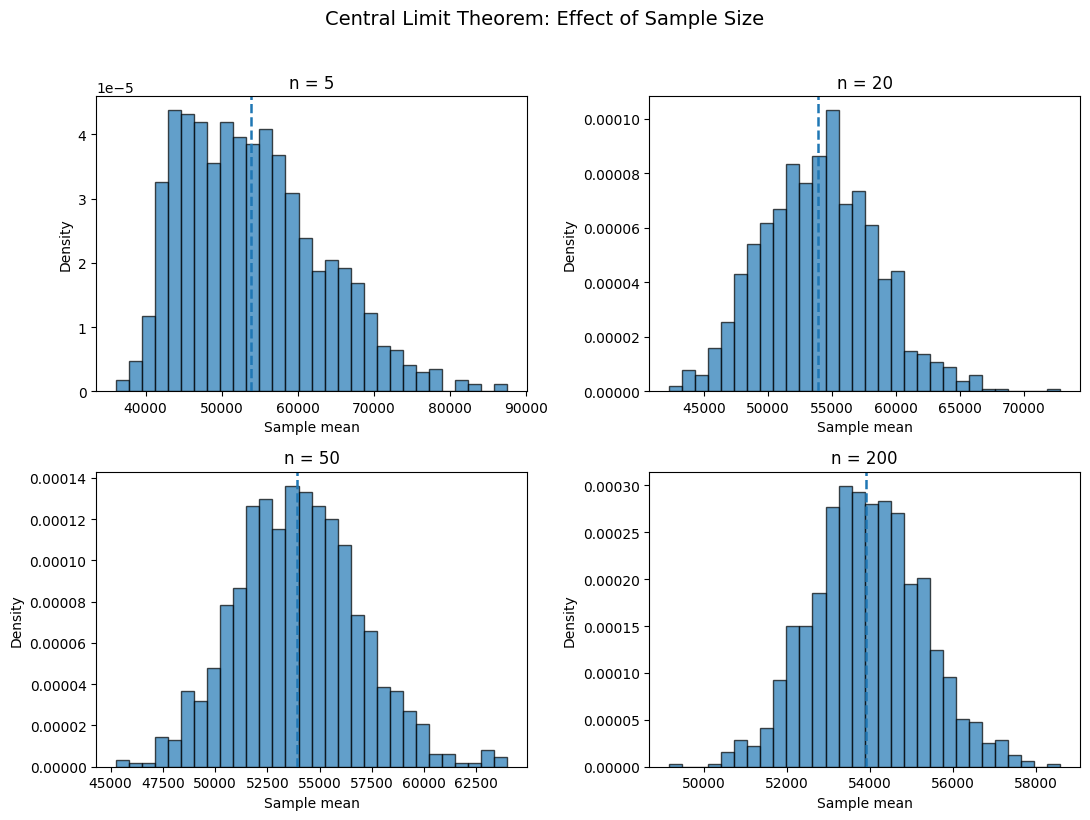

In [9]:
sample_sizes = [5, 20, 50, 200]
clt_results = {}

for n in sample_sizes:
    means = np.array([
        population["income"].sample(n=n, random_state=10_000 + i).mean()
        for i in range(1000)
    ])
    clt_results[n] = means

fig, axes = plt.subplots(2, 2, figsize=(11, 8))

for ax, n in zip(axes.ravel(), sample_sizes):
    ax.hist(clt_results[n], bins=30, density=True, alpha=0.7, edgecolor="black")
    ax.axvline(population["income"].mean(), linestyle="--", linewidth=1.8)
    ax.set_title(f"n = {n}")
    ax.set_xlabel("Sample mean")
    ax.set_ylabel("Density")

fig.suptitle("Central Limit Theorem: Effect of Sample Size", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

**Caption / Penjelasan Chart:** Ketika ukuran sample meningkat dari 5 menjadi 200, distribusi sample mean menjadi semakin sempit dan semakin menyerupai bentuk bell-shaped. Hal ini merupakan ilustrasi empiris dari CLT.

## 7. Standard Error

**Standard error (SE)** mengukur variasi sampling dari suatu statistic. Untuk sample mean:

**SE = s / √n**

dengan `s` sebagai sample standard deviation dan `n` sebagai sample size.

SE berbeda dari standard deviation. Standard deviation menggambarkan variasi observasi individual, sedangkan standard error menggambarkan variasi estimator dari satu sample ke sample lainnya.

In [10]:
se_table = []

for n in sample_sizes:
    empirical_se = clt_results[n].std(ddof=1)
    theoretical_se = population["income"].std(ddof=1) / np.sqrt(n)
    se_table.append([n, empirical_se, theoretical_se])

se_table = pd.DataFrame(
    se_table,
    columns=["Sample Size", "Empirical SE", "Approx. SE"]
)

display(se_table)

,Sample Size,Empirical SE,Approx. SE
0,5,"9,041.3323","8,859.1006"
1,20,"4,436.3983","4,429.5503"
2,50,"2,919.8247","2,801.4936"
3,200,"1,330.1859","1,400.7468"


**Interpretasi:** Empirical SE mendekati theoretical SE dan menurun ketika sample size meningkat. Pola ini menjelaskan mengapa estimasi berbasis sample yang lebih besar umumnya lebih presisi, selama kualitas dan representativeness sample tetap terjaga.

### Visualisasi 4 — Standard Error vs Sample Size

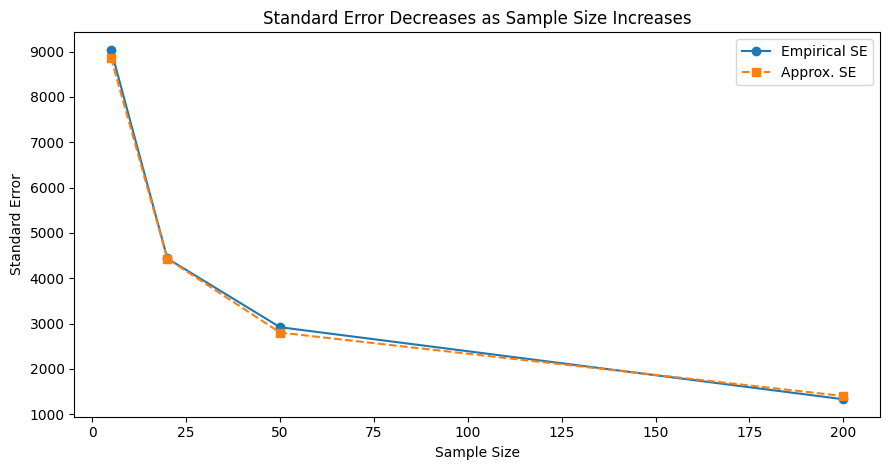

In [11]:
fig, ax = plt.subplots(figsize=(9, 4.8))

ax.plot(se_table["Sample Size"], se_table["Empirical SE"], marker="o", label="Empirical SE")
ax.plot(se_table["Sample Size"], se_table["Approx. SE"], marker="s", linestyle="--", label="Approx. SE")

ax.set_title("Standard Error Decreases as Sample Size Increases")
ax.set_xlabel("Sample Size")
ax.set_ylabel("Standard Error")
ax.legend()

plt.tight_layout()
plt.show()

**Caption / Penjelasan Chart:** Kedua kurva menunjukkan pola penurunan SE ketika sample size meningkat. Hubungan ini mengikuti prinsip `1/√n`, sehingga menggandakan sample size tidak menggandakan precision; peningkatan precision berlangsung dengan laju akar kuadrat.

## 8. The Bootstrap

**Bootstrap** adalah metode resampling yang mengambil observasi dari sample yang tersedia **dengan replacement** untuk membentuk banyak bootstrap samples.

Tujuan utamanya adalah mengestimasi sampling distribution suatu statistic ketika distribusi teoritisnya sulit diturunkan atau asumsi parametriknya tidak nyaman digunakan.

Berbeda dari mengambil sample baru dari population, bootstrap bekerja hanya dengan sample yang sudah dimiliki.

In [12]:
# Bootstrap untuk mengestimasi sampling distribution dari sample mean.
observed_sample = sample["income"].to_numpy()

bootstrap_means = np.array([
    rng.choice(observed_sample, size=len(observed_sample), replace=True).mean()
    for _ in range(5000)
])

print("Observed sample mean:", observed_sample.mean())
print("Bootstrap mean:", bootstrap_means.mean())
print("Bootstrap SE:", bootstrap_means.std(ddof=1))

Observed sample mean: 53728.062134227526
Bootstrap mean: 53743.17837943277
Bootstrap SE: 1386.5976145488776


### Visualisasi 5 — Bootstrap Distribution

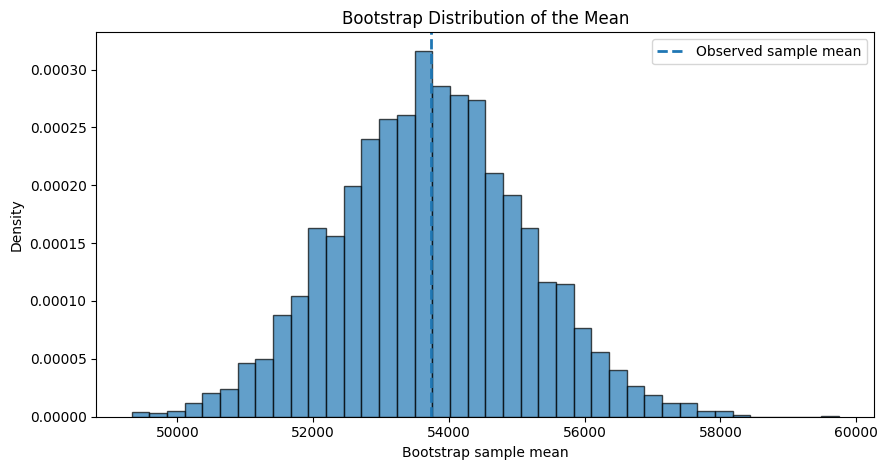

In [13]:
fig, ax = plt.subplots(figsize=(9, 4.8))

ax.hist(bootstrap_means, bins=40, density=True, alpha=0.7, edgecolor="black")
ax.axvline(observed_sample.mean(), linestyle="--", linewidth=2, label="Observed sample mean")
ax.set_title("Bootstrap Distribution of the Mean")
ax.set_xlabel("Bootstrap sample mean")
ax.set_ylabel("Density")
ax.legend()

plt.tight_layout()
plt.show()

**Caption / Penjelasan Chart:** Bootstrap distribution menggambarkan variasi sample mean yang diperkirakan berdasarkan sample yang tersedia. Penyebarannya memberikan informasi mengenai ketidakpastian estimator tanpa harus mengetahui bentuk distribusi population secara eksplisit.

## 9. Confidence Intervals

Confidence interval memberikan rentang nilai yang dibangun menggunakan prosedur statistik untuk mengestimasi parameter population.

Untuk bootstrap, interval percentile dapat diperoleh dari quantile bootstrap distribution. Misalnya, 95% bootstrap confidence interval menggunakan percentile 2.5% dan 97.5%.

Perlu diperhatikan bahwa confidence interval adalah pernyataan tentang **prosedur estimasi**, bukan probabilitas sederhana bahwa parameter tetap berada di dalam interval setelah interval dihitung.

In [14]:
ci_lower, ci_upper = np.percentile(bootstrap_means, [2.5, 97.5])

print(f"Observed mean : {observed_sample.mean():,.2f}")
print(f"95% Bootstrap CI: [{ci_lower:,.2f}, {ci_upper:,.2f}]")

Observed mean : 53,728.06
95% Bootstrap CI: [51,051.93, 56,525.31]


### Visualisasi 6 — Bootstrap Confidence Interval

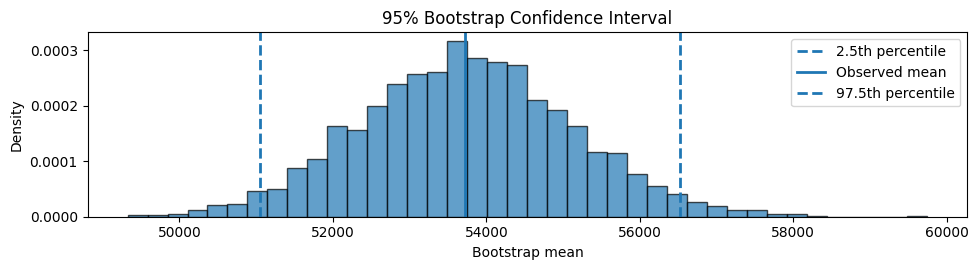

In [15]:
fig, ax = plt.subplots(figsize=(10, 2.8))

ax.hist(bootstrap_means, bins=40, density=True, alpha=0.7, edgecolor="black")
ax.axvline(ci_lower, linestyle="--", linewidth=2, label="2.5th percentile")
ax.axvline(observed_sample.mean(), linestyle="-", linewidth=2, label="Observed mean")
ax.axvline(ci_upper, linestyle="--", linewidth=2, label="97.5th percentile")

ax.set_title("95% Bootstrap Confidence Interval")
ax.set_xlabel("Bootstrap mean")
ax.set_ylabel("Density")
ax.legend()

plt.tight_layout()
plt.show()

**Caption / Penjelasan Chart:** Dua garis putus-putus menunjukkan batas percentile 2.5% dan 97.5%. Area di antara kedua batas tersebut merupakan 95% bootstrap percentile interval untuk mean berdasarkan sample yang tersedia.

## 10. Normal Distribution

Distribusi normal memiliki bentuk bell-shaped yang simetris dengan parameter mean `μ` dan standard deviation `σ`.

Fungsi density-nya adalah:

**f(x) = 1/(σ√(2π)) × exp(−(x−μ)²/(2σ²))**

Normal distribution penting karena muncul dalam banyak prosedur statistik dan juga menjadi pendekatan untuk sampling distribution melalui CLT.

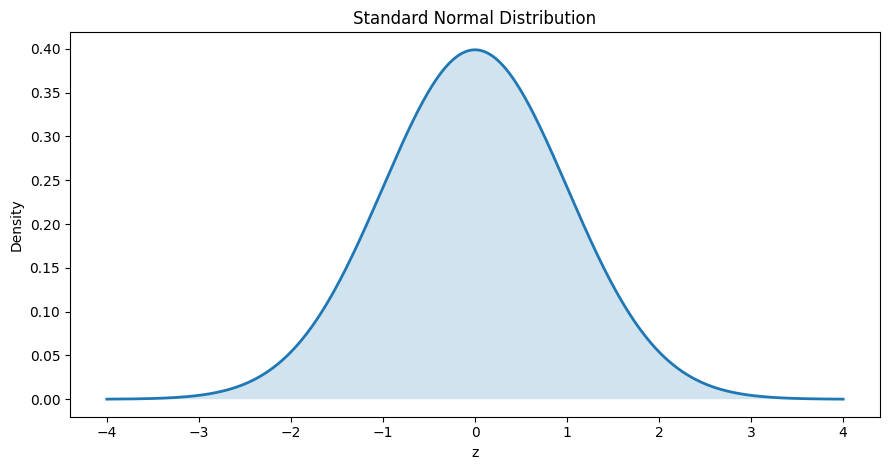

In [16]:
mu, sigma = 0, 1
x = np.linspace(-4, 4, 500)
normal_pdf = stats.norm.pdf(x, loc=mu, scale=sigma)

fig, ax = plt.subplots(figsize=(9, 4.8))
ax.plot(x, normal_pdf, linewidth=2)
ax.fill_between(x, normal_pdf, alpha=0.2)
ax.set_title("Standard Normal Distribution")
ax.set_xlabel("z")
ax.set_ylabel("Density")
plt.tight_layout()
plt.show()

**Caption / Penjelasan Chart:** Standard normal memiliki mean 0 dan standard deviation 1. Kurva simetris terhadap nol dan sebagian besar probability mass berada dekat pusat distribusi.

## 11. Standard Normal dan QQ-Plot

Standardization mengubah nilai `x` menjadi z-score:

**z = (x − μ) / σ**

QQ-plot membandingkan quantile data dengan quantile theoretical distribution. Jika titik mengikuti garis lurus, data memiliki bentuk yang relatif konsisten dengan distribusi yang diuji.

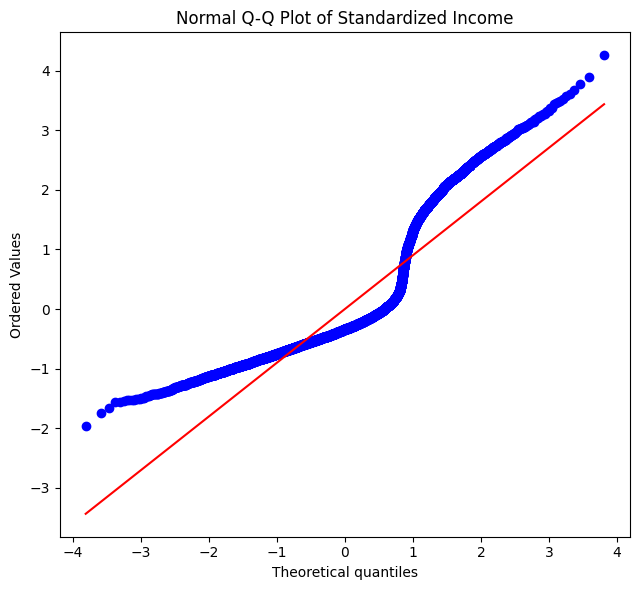

In [17]:
z_income = (population["income"] - population["income"].mean()) / population["income"].std(ddof=1)

fig, ax = plt.subplots(figsize=(6.5, 6))
stats.probplot(z_income, dist="norm", plot=ax)
ax.set_title("Normal Q-Q Plot of Standardized Income")
plt.tight_layout()
plt.show()

**Caption / Penjelasan Chart:** QQ-plot memperlihatkan seberapa dekat quantile standardized income dengan quantile normal. Penyimpangan pada bagian ekor mengindikasikan bahwa distribusi income tidak sepenuhnya normal, terutama karena adanya tail yang lebih berat.

## 12. Long-Tailed Distributions

Distribusi long-tailed memiliki probability mass yang relatif lebih besar pada bagian ekor dibandingkan normal distribution. Dalam data science, long tails penting karena observasi ekstrem dapat lebih sering muncul dan memengaruhi mean, standard deviation, serta model.

Contoh sederhana adalah lognormal distribution.

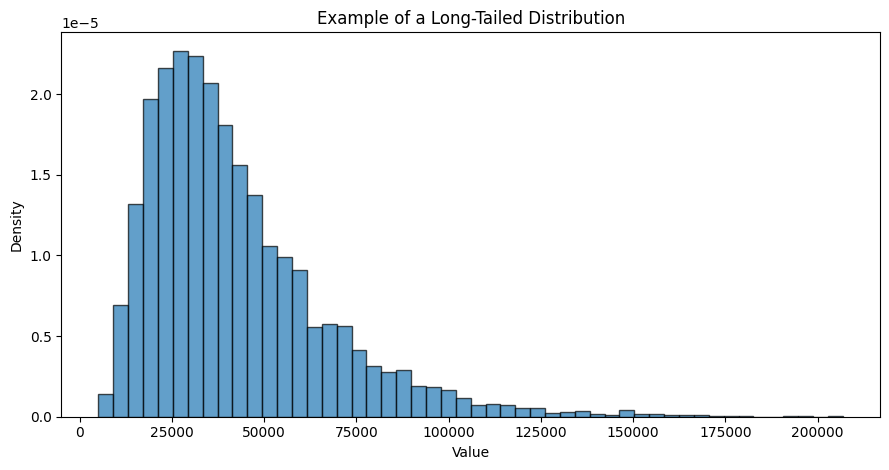

In [18]:
rng = np.random.default_rng(123)
lognormal_data = rng.lognormal(mean=10.5, sigma=0.55, size=5000)

fig, ax = plt.subplots(figsize=(9, 4.8))
ax.hist(lognormal_data, bins=50, density=True, alpha=0.7, edgecolor="black")
ax.set_title("Example of a Long-Tailed Distribution")
ax.set_xlabel("Value")
ax.set_ylabel("Density")
plt.tight_layout()
plt.show()

**Caption / Penjelasan Chart:** Distribusi lognormal memiliki ekor kanan panjang. Kondisi ini menunjukkan mengapa mean dapat berada jauh di atas median ketika data sangat right-skewed.

## 13. Student's t-Distribution

Student's t-distribution menyerupai normal distribution tetapi memiliki ekor yang lebih tebal. Distribusi ini banyak digunakan ketika standard deviation population tidak diketahui dan sample size relatif kecil.

Parameter `df` atau degrees of freedom mengontrol ketebalan ekor. Ketika `df` semakin besar, bentuk t-distribution semakin mendekati normal distribution.

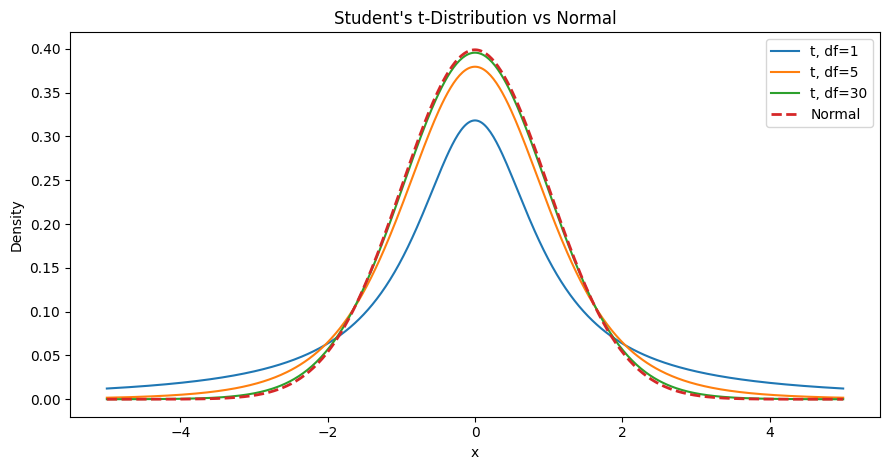

In [19]:
x = np.linspace(-5, 5, 500)

fig, ax = plt.subplots(figsize=(9, 4.8))
for df in [1, 5, 30]:
    ax.plot(x, stats.t.pdf(x, df), label=f"t, df={df}")

ax.plot(x, stats.norm.pdf(x), linestyle="--", linewidth=2, label="Normal")
ax.set_title("Student's t-Distribution vs Normal")
ax.set_xlabel("x")
ax.set_ylabel("Density")
ax.legend()

plt.tight_layout()
plt.show()

**Caption / Penjelasan Chart:** t-distribution dengan degrees of freedom rendah memiliki ekor paling tebal. Ketika df meningkat, kurva semakin dekat dengan standard normal distribution.

## 14. Binomial Distribution

Binomial distribution digunakan ketika terdapat sejumlah `n` percobaan Bernoulli yang independen, setiap percobaan hanya memiliki dua outcome, dan probability sukses `p` konstan.

Probability tepat `k` sukses adalah:

**P(X=k) = C(n,k) p^k (1−p)^(n−k)**

Distribusi ini cocok untuk menghitung jumlah keberhasilan dalam sejumlah percobaan, misalnya jumlah klik dari sejumlah impression jika setiap trial didefinisikan sebagai sukses/gagal.

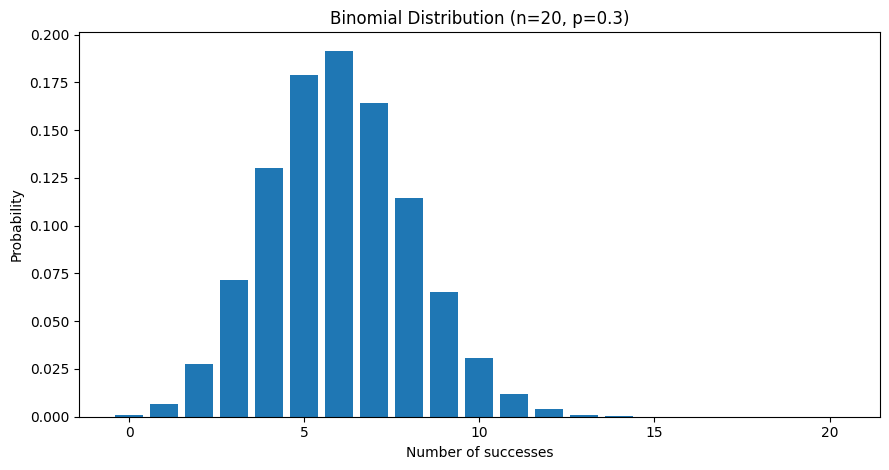

In [20]:
n = 20
p = 0.30
k = np.arange(0, n + 1)
pmf_binom = stats.binom.pmf(k, n, p)

fig, ax = plt.subplots(figsize=(9, 4.8))
ax.bar(k, pmf_binom, width=0.8)
ax.set_title(f"Binomial Distribution (n={n}, p={p})")
ax.set_xlabel("Number of successes")
ax.set_ylabel("Probability")
plt.tight_layout()
plt.show()

**Caption / Penjelasan Chart:** Dengan `n=20` dan `p=0.30`, probability terbesar berada di sekitar jumlah sukses yang mendekati `np = 6`. Bentuk distribusi mencerminkan kemungkinan jumlah sukses dari 20 percobaan.

## 15. Chi-Square Distribution

Chi-square distribution terbentuk dari jumlah kuadrat beberapa standard normal independent random variables. Parameter utamanya adalah degrees of freedom.

Distribusi ini banyak muncul pada inference untuk variance dan chi-square tests pada categorical data.

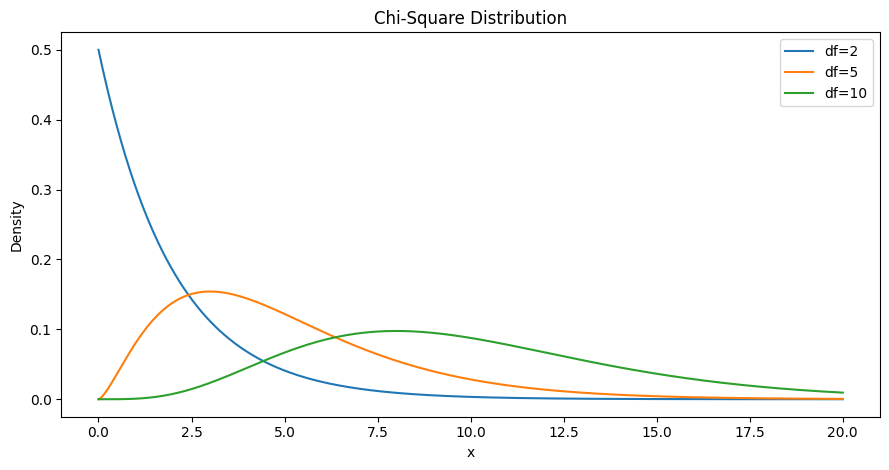

In [21]:
x = np.linspace(0, 20, 500)

fig, ax = plt.subplots(figsize=(9, 4.8))
for df in [2, 5, 10]:
    ax.plot(x, stats.chi2.pdf(x, df), label=f"df={df}")

ax.set_title("Chi-Square Distribution")
ax.set_xlabel("x")
ax.set_ylabel("Density")
ax.legend()
plt.tight_layout()
plt.show()

**Caption / Penjelasan Chart:** Chi-square distribution bersifat non-negative dan right-skewed terutama pada degrees of freedom kecil. Ketika df meningkat, distribusi menjadi lebih simetris dan pusatnya bergeser ke nilai yang lebih besar.

## 16. F-Distribution

F-distribution berkaitan dengan rasio dua scaled chi-square variables. Distribusi ini penting dalam perbandingan variance dan ANOVA.

Karena berbentuk non-negative dan umumnya right-skewed, interpretasi F-statistic menggunakan area pada ekor kanan.

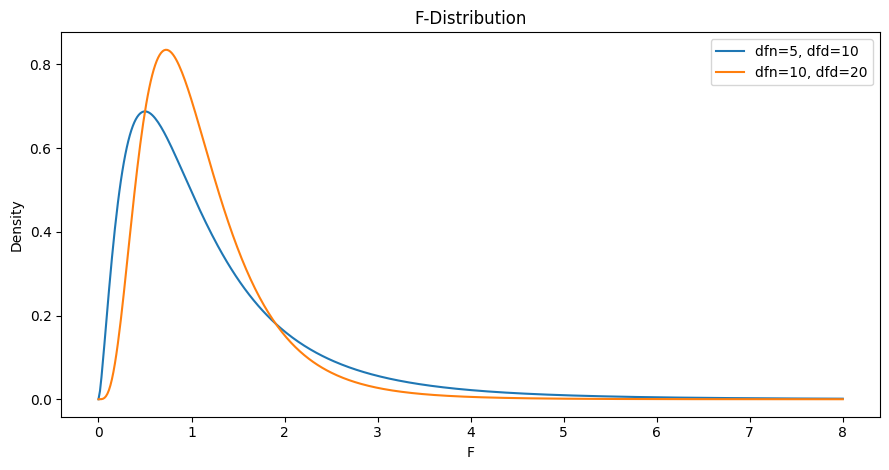

In [22]:
x = np.linspace(0, 8, 500)

fig, ax = plt.subplots(figsize=(9, 4.8))
for dfn, dfd in [(5, 10), (10, 20)]:
    ax.plot(x, stats.f.pdf(x, dfn, dfd), label=f"dfn={dfn}, dfd={dfd}")

ax.set_title("F-Distribution")
ax.set_xlabel("F")
ax.set_ylabel("Density")
ax.legend()
plt.tight_layout()
plt.show()

**Caption / Penjelasan Chart:** F-distribution hanya memiliki nilai non-negative dan memiliki ekor kanan. Bentuknya dipengaruhi oleh dua degrees of freedom, yaitu numerator dan denominator degrees of freedom.

## 17. Poisson Distribution

Poisson distribution memodelkan jumlah kejadian dalam interval waktu atau ruang tertentu ketika kejadian terjadi secara independen dengan rata-rata rate `λ`.

Probability tepat `k` kejadian:

**P(X=k) = e^(−λ) λ^k / k!**

Contoh penerapannya antara lain jumlah kedatangan pelanggan per menit atau jumlah error per satuan waktu.

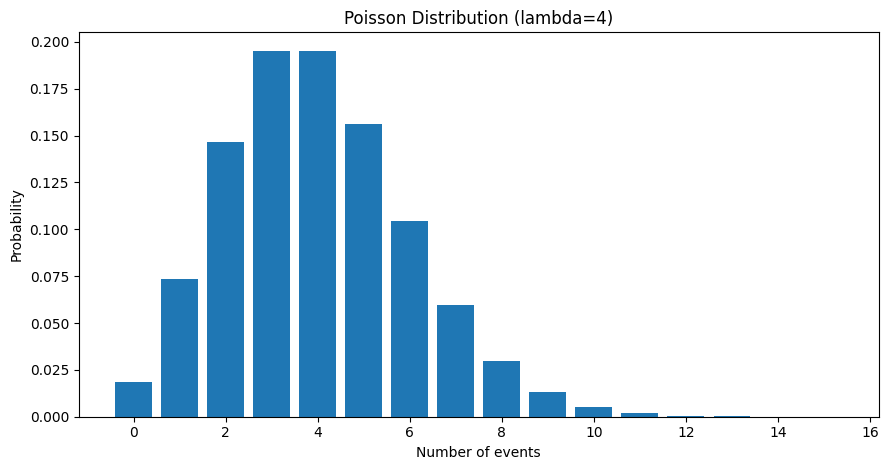

In [23]:
lam = 4
k = np.arange(0, 16)
pmf_poisson = stats.poisson.pmf(k, lam)

fig, ax = plt.subplots(figsize=(9, 4.8))
ax.bar(k, pmf_poisson, width=0.8)
ax.set_title(f"Poisson Distribution (lambda={lam})")
ax.set_xlabel("Number of events")
ax.set_ylabel("Probability")
plt.tight_layout()
plt.show()

**Caption / Penjelasan Chart:** Untuk λ=4, jumlah kejadian paling mungkin berada di sekitar 4. Nilai λ sekaligus merupakan mean dan variance dari Poisson distribution.

## 18. Exponential Distribution

Exponential distribution sering digunakan untuk memodelkan waktu tunggu hingga kejadian berikutnya pada proses Poisson.

Jika rate adalah `λ`, maka mean waiting time adalah:

**E(X) = 1/λ**

Distribution ini memiliki memoryless property: probabilitas menunggu lebih lama tidak bergantung pada berapa lama sudah menunggu.

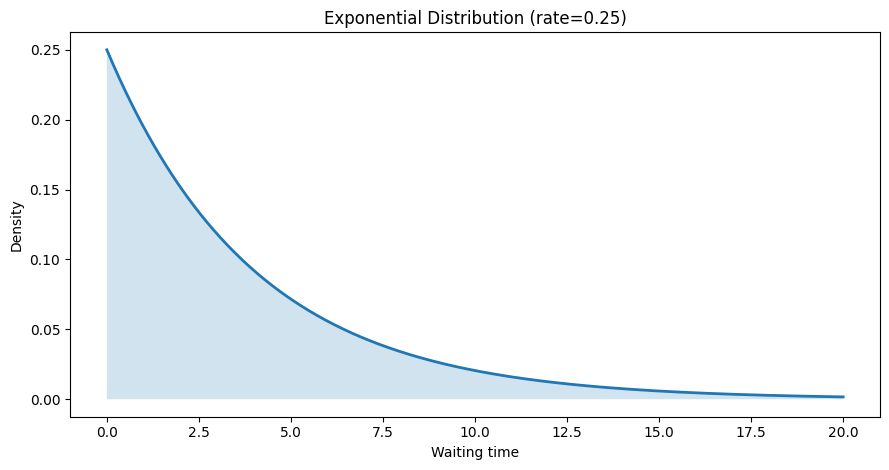

In [24]:
rate = 0.25
x = np.linspace(0, 20, 500)
pdf_exp = stats.expon.pdf(x, scale=1/rate)

fig, ax = plt.subplots(figsize=(9, 4.8))
ax.plot(x, pdf_exp, linewidth=2)
ax.fill_between(x, pdf_exp, alpha=0.2)
ax.set_title(f"Exponential Distribution (rate={rate})")
ax.set_xlabel("Waiting time")
ax.set_ylabel("Density")
plt.tight_layout()
plt.show()

**Caption / Penjelasan Chart:** Exponential distribution memiliki density tertinggi dekat nol dan menurun secara eksponensial. Dengan rate 0.25, expected waiting time adalah 4 unit waktu.

## 19. Weibull Distribution dan Failure Rate

Weibull distribution sering digunakan pada reliability engineering untuk memodelkan lifetime dan failure behavior.

Bentuk hazard/failure rate bergantung pada shape parameter:

- `k < 1`: failure rate menurun.
- `k = 1`: failure rate konstan, ekuivalen dengan exponential.
- `k > 1`: failure rate meningkat.

Konsep ini penting ketika data digunakan untuk menganalisis reliability atau lifetime suatu komponen.

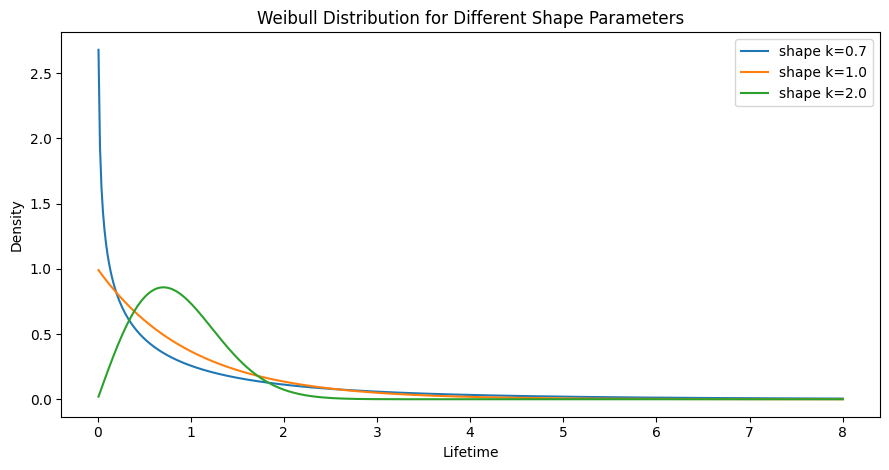

In [25]:
x = np.linspace(0.01, 8, 500)

fig, ax = plt.subplots(figsize=(9, 4.8))
for k_shape in [0.7, 1.0, 2.0]:
    ax.plot(
        x,
        stats.weibull_min.pdf(x, c=k_shape),
        label=f"shape k={k_shape}"
    )

ax.set_title("Weibull Distribution for Different Shape Parameters")
ax.set_xlabel("Lifetime")
ax.set_ylabel("Density")
ax.legend()
plt.tight_layout()
plt.show()

**Caption / Penjelasan Chart:** Perubahan shape parameter mengubah karakter distribusi lifetime. Saat `k=1`, Weibull menjadi exponential. Ketika `k>1`, probability mass bergeser sehingga model dapat merepresentasikan proses dengan failure rate yang meningkat.

## 20. Perbandingan Distribusi Utama

Berbagai probability distributions memiliki karakteristik dan konteks penggunaan yang berbeda. Pemilihan distribusi tidak boleh hanya berdasarkan bentuk chart; konteks proses pembangkitan data dan asumsi statistik juga harus dipertimbangkan.

In [26]:
distribution_summary = pd.DataFrame({
    "Distribution": [
        "Normal", "Student's t", "Binomial", "Chi-Square",
        "F", "Poisson", "Exponential", "Weibull"
    ],
    "Typical Use": [
        "Continuous symmetric measurements",
        "Inference for means with unknown population SD",
        "Number of successes in n trials",
        "Variance / categorical inference",
        "Variance ratios / ANOVA",
        "Event counts",
        "Waiting times",
        "Lifetime / reliability"
    ]
})

display(distribution_summary)

,Distribution,Typical Use
0,Normal,Continuous symmetric measurements
1,Student's t,Inference for means with unknown population SD
2,Binomial,Number of successes in n trials
3,Chi-Square,Variance / categorical inference
4,F,Variance ratios / ANOVA
5,Poisson,Event counts
6,Exponential,Waiting times
7,Weibull,Lifetime / reliability


## 21. Hubungan Chapter 2 dengan Machine Learning dan Deep Learning

Konsep sampling dan probability distribution memiliki hubungan langsung dengan machine learning:

1. **Train-test split** merupakan bentuk sampling dari data yang tersedia.
2. **Sampling bias** dapat membuat training data tidak representatif terhadap deployment population.
3. **Bootstrap** dapat digunakan untuk mengukur ketidakpastian performa model.
4. **Confidence interval** membantu menyampaikan ketidakpastian estimasi.
5. **Distribution shift** berkaitan dengan perbedaan distribusi data training dan data yang ditemui model setelah deployment.
6. **Probability distributions** menjadi dasar banyak model statistik dan probabilistic machine learning.
7. Pada Deep Learning, random initialization, minibatch sampling, dan stochastic optimization juga membuat sampling dan variability menjadi konsep penting.

Dengan demikian, memahami distribusi data dan sampling membantu kita menilai apakah hasil model benar-benar stabil atau hanya merupakan artefak dari sample tertentu.

## 22. Ringkasan Chapter

| Konsep | Inti Pemahaman |
|---|---|
| Population & sample | Sample adalah subset yang digunakan untuk mempelajari population |
| Random sampling | Mengurangi risiko systematic selection bias |
| Sampling bias | Prosedur sampling dapat menghasilkan estimasi yang tidak representatif |
| Sampling distribution | Distribusi dari suatu statistic pada banyak sample |
| Central Limit Theorem | Sampling distribution mean cenderung mendekati normal ketika n membesar |
| Standard error | Mengukur variability dari estimator |
| Bootstrap | Resampling with replacement untuk mengestimasi sampling distribution |
| Confidence interval | Rentang estimasi yang dibangun berdasarkan prosedur inferensi |
| Normal | Distribusi kontinu simetris berbentuk bell |
| Student's t | Memiliki tail lebih berat daripada normal |
| Binomial | Jumlah sukses dari n trial |
| Chi-square | Distribusi non-negative berbasis squared standard normals |
| F | Rasio dua scaled chi-square distributions |
| Poisson | Jumlah kejadian dalam interval |
| Exponential | Waktu tunggu antar-kejadian |
| Weibull | Lifetime dan reliability |

### Kesimpulan

Chapter 2 menjelaskan bahwa kualitas inferensi tidak hanya bergantung pada jumlah data. **Bagaimana data dipilih, bagaimana sample statistic bervariasi, dan bagaimana ketidakpastian diukur** sama pentingnya. Konsep-konsep tersebut menjadi dasar untuk statistical inference, experiment design, dan evaluasi model machine learning.

## 23. Referensi

1. Bruce, P., Bruce, A., & Gedeck, P. (2020). *Practical Statistics for Data Scientists: 50+ Essential Concepts Using R and Python* (2nd ed.). O'Reilly Media.
2. Gedeck, P. et al. *Practical Statistics for Data Scientists* — official code repository.
3. SciPy documentation untuk probability distributions dan statistical functions.

**Catatan akademik:** Implementasi pada notebook ini ditulis ulang untuk tujuan reproduksi dan pembelajaran. Struktur topik mengikuti Chapter 2 buku, sedangkan data simulasi digunakan pada bagian yang bertujuan memperlihatkan konsep sampling dan probability distributions secara terkontrol.